In [95]:
ClearAll["Global`*"];
Remove["Global`*"];

In [97]:
cutthres = 1.0*^-60;
precisthres = 100;

In [99]:
cutoff[x_] := If[x < cutthres, 0.0, x];

In [100]:
csqe[ntot_,T_,r_,klist_] :=
(
    res = {};
    
    khead = "/home/loglab/Desktop/primo_ODE/ratelist_";
    csvext = ".csv";
    data = Import[khead <> klist <> csvext,"Table"];
    
    kvalue = data[[T]];
    SetPrecision[kvalue,20];
    kcutoff = cutoff /@ kvalue;
    
    remain = {0.0, 0.0, 0.0, 0.0, 0.0, 0.0};

    nH = ntot * (r[[1]] / Total[r]);
    nHe = ntot * (r[[2]] / Total[r]);
    
    k1 = kcutoff[[2]];
    k2 = kcutoff[[3]];
    k3 = kcutoff[[4]];
    k4 = kcutoff[[5]];
    k5 = kcutoff[[6]];
    k6 = kcutoff[[7]];
    k7 = kcutoff[[8]];
    k8 = kcutoff[[9]];
    k9 = kcutoff[[10]];
    k10 = kcutoff[[11]];
    k11 = kcutoff[[12]];
    k12 = kcutoff[[13]];
    k13 = kcutoff[[14]];
    k14 = kcutoff[[15]];
    k15 = kcutoff[[16]];
    k16 = kcutoff[[17]];
    k17 = kcutoff[[18]];
    k18 = kcutoff[[19]];
    k19 = kcutoff[[20]];

    k20 = kcutoff[[21]];
    k21 = kcutoff[[22]];
    k22 = kcutoff[[23]];
    k23 = kcutoff[[24]];
    k24 = kcutoff[[25]];
    k25 = kcutoff[[26]];
    k26 = kcutoff[[27]];
    k27 = kcutoff[[28]];
    k28 = kcutoff[[29]];

    eq1 = -k2 y y + (k1 - k9) y x - k11 w y + (k2 - k16 - k17) z y - k2 v y - k2 b y - 2 k2 c y - k1 z x + (k10 + k1) v x + k1 b x + 2 k1 c x + (k20 x + k25 v) / ntot == remain[[1]];
    eq2 = -k13 w x - (k11 + k12) w y + k12 z w - k12 v w - k12 b w - 2k12 c w + k8 z x + k10 v x + k19 v z + (-k24 w - (k27 + k28) w) / ntot == remain[[2]];
    eq3 = k14 z z - (k7 + k8 + k15) z x - (k14 + k16 + k17) z y - (k14 + k19) v z - k14 b z - 2 k14 c z + k7 y x + k7 v x + k7 b x + 2 k7 c x - k23 z / ntot == remain[[3]];
    eq4 = -k18 v v - k10 v x - k18 v y + (k18 - k19) v z - k18 b v - 2 k18 c v + k9 y x + k11 w y + k17 z y + (k24 w - k25 v - k26 v) / ntot == remain[[4]];
    eq5 = -k3 a y +  k3 a z -  k3 a v -  k3 b a - 2k3 c a + k4 b y - k4 b z + k4 b v + k4 b b + 2 k4 c b - k21 a / ntot == remain[[5]];
    eq6 = -2 k6 c c - k6 c y + k6 c z - k6 c v + (2k5 - k6) c b + k5 b y - k5 b z + k5 b v + k5 b b + k22 b / ntot == remain[[6]];
    eq7 = x + y + 2 w + z + 2 v == nH / ntot;
    eq8 = a + b + c == nHe / ntot;
    
    eq9 = x + y + 2 w + z + 2 v + a + b + c == 1.0;

(*
    k20 = 0.0;
    k21 = 0.0;
    k22 = 0.0;
    k23 = 0.0;
    k24 = 0.0;
    k25 = 0.0;
    k26 = 0.0;
    k27 = 0.0;
    k28 = 0.0;
    
    eq1 = -k2 y y + (k1 - k9) y x - k11 w y + (k2 - k16 - k17) z y - k2 v y - k2 b y - 2 k2 c y - k1 z x + (k10 + k1) v x + k1 b x + 2 k1 c x == remain[[1]];
    eq2 = -k13 w x - (k11 + k12) w y + k12 z w - k12 v w - k12 b w - 2k12 c w + k8 z x + k10 v x + k19 v z == remain[[2]];
    eq3 = k14 z z - (k7 + k8 + k15) z x - (k14 + k16 + k17) z y - (k14 + k19) v z - k14 b z - 2 k14 c z + k7 y x + k7 v x + k7 b x + 2 k7 c x == remain[[3]];
    eq4 = -k18 v v - k10 v x - k18 v y + (k18 - k19) v z - k18 b v - 2 k18 c v + k9 y x + k11 w y + k17 z y == remain[[4]];
    eq5 = -k3 a y +  k3 a z -  k3 a v -  k3 b a - 2k3 c a + k4 b y - k4 b z + k4 b v + k4 b b + 2 k4 c b == remain[[5]];
    eq6 = -2 k6 c c - k6 c y + k6 c z - k6 c v + (2k5 - k6) c b + k5 b y - k5 b z + k5 b v + k5 b b == remain[[6]];
    eq7 = x + y + 2 w + z + 2 v == nH / ntot;
    eq8 = a + b + c == nHe / ntot;
*)

    res = NSolve[(eq1) && (eq2) && (eq3) && (eq4) && (eq5) && (eq6) && (eq7) && (eq8) && (0 <= x <= nH) && (0 <= y <= nH) && (0 <= w <= nH) && (0 <= z <= nH) && (0 <= v <= nH) && (0 <= a <= nHe) && (0 <= b <= nHe) && (0 <= c <= nHe), {x,y,w,z,v,a,b,c}, Reals, WorkingPrecision -> precisthres][[-1]];

(*
    res = NSolve[(eq1) && (eq2) && (eq3) && (eq4) && (eq5) && (eq6) && (eq7) && (eq8) && (0 <= x <= nH) && (0 <= y <= nH) && (0 <= w <= nH) && (0 <= z <= nH) && (0 <= v <= nH) && (0 <= a <= nHe) && (0 <= b <= nHe) && (0 <= c <= nHe), {x,y,w,z,v,a,b,c}, Reals][[-1]];
*)
    res = res /. Rule[a_,b_] :> b;
    res = Flatten[{klist,r,ntot,T,res}]

)

In [101]:

ntot = {1,2,5,10,20,50,100,200,500,1000};
T = {10,20,50,100,200,500,1000,2000,5000,10000};

(*
ntot = {25,75,100};
T = {2500,7500};
*)

r = {{1.3,0.7},{9,1},{12,1}};
klist = {
"black_-32",
"const_-11_3",
"power_-9_3",
"black_-28",
"const_-7_3",
"power_-5_3"
};

In [49]:
Export["eqtable_raw.csv",csqe[1000,1000,r[[1]],"CMB_4000"],"Table"]

NSolve::precw:                                                                         -9                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      -12
                                              0.000667292 v + 1.41871 10   x             -60                 -60             -10                 -12                 -12                 -12                 -50                -18                 -12  2             -60                 -8                     -11               -54                 -53                 -54             -10                 -37                 -50                 -7                 -54               -9                     -16                 -15                 -16                 -16                             -13                -13                 -7                 -9                 -8                 -13  2                 -9                 -8                 -9  2   -0.000667292 v + 4.73886 10    w         -10                 -9                 -50                -18                 -7                 -10                    -26               -105                 -12  2             -104                 -12                 -105                 -12                 -105                 -12                 -105                 -12                     -63               -12                 -11  2             -12                 -12                 -12
The precision of the argument function ({0. + ------------------------------ + 1.88692 10    b x + 3.77385 10    c x + 6.4 10    v x - 2.00735 10    b y - 4.01469 10    c y - 2.00735 10    v y - 1.03879 10    w y - 4.6474 10    x y - 2.00735 10    y  - 1.88692 10    x z - 2.27447 10   y z, 0. - 3.75767 10    w - 7.87587 10    b w - 1.57517 10    c w - 7.87587 10    v w + 6.4 10    v x - 4.62774 10    w x - 1.03958 10    w y + 1.58114 10   v z + 7.87587 10    w z + 1.428 10   x z, 0. + 8.46744 10    b x + 1.69349 10    c x + 8.46744 10    v x + 8.46744 10    x y - 605.843 z - 4.53365 10    b z - 9.0673 10    c z - 1.58114 10   v z - 1.46049 10   x z - 2.27472 10   y z + 4.53365 10    z , 0. - 6.92746 10   b v - 1.38549 10   c v - 6.92746 10   v  + -------------------------------- - 6.4 10    v x - 6.92746 10   v y + 1.03879 10    w y + 4.6474 10    x y - 1.51186 10   v z + 6.10768 10    y z, 0. - 6.2469 10    a - 5.10025 10     a b + 1.86293 10    b  - 1.02005 10     a c + 3.72587 10    b c - 5.10025 10     a v + 1.86293 10    b v - 5.10025 10     a y + 1.86293 10    b y + 5.10025 10     a z - 1.86293 10    b z, 0. + 1.91606 10    b - 9.74681 10    b c - 1.94936 10    c  - 9.74681 10    c v - 9.74681 10    c y + 9.74681 10    c z, -0.65 + 2 v + 2 w + x + y + z, -0.35 + a + b + c}) is less than WorkingPrecision (60).
                                                           1000                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    1000

Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.: Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.

Part::partw: Part -1 of {} does not exist.

eqtable_raw.csv

In [111]:
dataset = Table[Table[csqe[x1,x2,r[[1]],"CMB_2000"],{x2,T}],{x1,ntot}];

Export["eqtable_sample.csv",Flatten[dataset,1],"Table"]

NSolve::precw:                                                         -11               -27           -10                 -11                 -11                 -11                 -21                 -11  2             -7                     -24           -10                 -6               -9                     -17                 -17                 -17                 -17                            -6                 -9                 -7                     -11          -8            -8            -8  2             -32           -10            -8                 -21                 -6                 -9                     -54               -11  2             -11                 -11                 -11                 -11                     -10                 -10  2             -10                 -10                 -10
The precision of the argument function ({0. + 2.25301 10    v + 4.68817 10    x + 6.4 10    v x - 3.45088 10    b y - 6.90175 10    c y - 3.45088 10    v y - 1.16737 10    x y - 3.45088 10    y  - 2.25179 10   y z, 0. - 2.27721 10    w + 6.4 10    v x + 1.58114 10   v z + 1.428 10   x z, 0. + 1.08791 10    b x + 2.17582 10    c x + 1.08791 10    v x + 1.08791 10    x y - 15133. z - 1.58114 10   v z - 1.42801 10   x z - 2.25213 10   y z, 0. - 2.25301 10    v - 1. 10   b v - 2. 10   c v - 1. 10   v  + 6.20907 10    w - 6.4 10    v x - 1. 10   v y + 1.16737 10    x y - 1.57114 10   v z + 3.85368 10   y z, 0. - 3.14912 10    a + 3.47374 10    b  + 6.94748 10    b c + 3.47374 10    b v + 3.47374 10    b y - 3.47374 10    b z, 0. - 1.52607 10    b c - 3.05213 10    c  - 1.52607 10    c v - 1.52607 10    c y + 1.52607 10    c z, -0.65 + 2 v + 2 w + x + y + z, -0.35 + a + b + c}) is less than WorkingPrecision (100).

Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.: Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.

NSolve::precw:                                                         -11               -27           -10                 -11                 -11                 -11                 -21                 -11  2             -7                     -24           -10                 -6               -9                     -17                 -17                 -17                 -17                            -6                 -9                 -7                     -11          -8            -8            -8  2             -32           -10            -8                 -21                 -6                 -9                     -54               -11  2             -11                 -11                 -11                 -11                    -10                 -10  2            -10                -10                -10
The precision of the argument function ({0. + 2.25301 10    v + 4.68817 10    x + 6.4 10    v x - 2.29003 10    b y - 4.58006 10    c y - 2.29003 10    v y - 4.06503 10    x y - 2.29003 10    y  - 1.59422 10   y z, 0. - 2.27721 10    w + 6.4 10    v x + 1.11803 10   v z + 1.428 10   x z, 0. + 2.14838 10    b x + 4.29676 10    c x + 2.14838 10    v x + 2.14838 10    x y - 15133. z - 1.11803 10   v z - 1.42803 10   x z - 1.59445 10   y z, 0. - 2.25301 10    v - 1. 10   b v - 2. 10   c v - 1. 10   v  + 6.20907 10    w - 6.4 10    v x - 1. 10   v y + 4.06503 10    x y - 1.10803 10   v z + 2.92055 10   y z, 0. - 3.14912 10    a + 2.23642 10    b  + 4.47284 10    b c + 2.23642 10    b v + 2.23642 10    b y - 2.23642 10    b z, 0. - 1.0306 10    b c - 2.06119 10    c  - 1.0306 10    c v - 1.0306 10    c y + 1.0306 10    c z, -0.65 + 2 v + 2 w + x + y + z, -0.35 + a + b + c}) is less than WorkingPrecision (100).

Subsystem could not be solved for `1` at value `2`. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.:                                   -139306 a   113347 b   134851 c   168848 v   133381 w   58857 x   135062 y   35780 z                                                                                    17        -56
Subsystem could not be solved for --------- + -------- - -------- + -------- - -------- - ------- - -------- + ------- at value -2.09689603102352112255722207001873450549358912779463922651707452463458 10   + 0. 10    I. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.
                                   118839      118839     118839     118839     118839     39613     118839     39613

Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.: Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.

Part::partw: Part -1 of {} does not exist.

NSolve::precw:                                                         -11               -27           -10                 -11                 -11                 -11                 -20                 -11  2             -7                     -24           -10                 -7               -9                     -17                 -16                 -17                 -17                            -7                 -9                 -7                     -11          -8            -8            -8  2             -32           -10            -8                 -20                 -7                 -9                     -54               -11  2             -11                 -11                 -11                 -11                     -11                 -10  2             -11                 -11                 -11
The precision of the argument function ({0. + 2.25301 10    v + 4.68817 10    x + 6.4 10    v x - 1.31749 10    b y - 2.63497 10    c y - 1.31749 10    v y - 2.11522 10    x y - 1.31749 10    y  - 1.01006 10   y z, 0. - 2.27721 10    w + 6.4 10    v x + 7.07107 10   v z + 1.428 10   x z, 0. + 5.35429 10    b x + 1.07086 10    c x + 5.35429 10    v x + 5.35429 10    x y - 15133. z - 7.07107 10   v z - 1.42816 10   x z - 1.01019 10   y z, 0. - 2.25301 10    v - 1. 10   b v - 2. 10   c v - 1. 10   v  + 6.20907 10    w - 6.4 10    v x - 1. 10   v y + 2.11522 10    x y - 6.97107 10   v z + 2.02436 10   y z, 0. - 3.14912 10    a + 1.24952 10    b  + 2.49903 10    b c + 1.24952 10    b v + 1.24952 10    b y - 1.24952 10    b z, 0. - 6.05377 10    b c - 1.21075 10    c  - 6.05377 10    c v - 6.05377 10    c y + 6.05377 10    c z, -0.65 + 2 v + 2 w + x + y + z, -0.35 + a + b + c}) is less than WorkingPrecision (100).

Further output of `1` will be suppressed during this calculation.: Further output of NSolve::precw will be suppressed during this calculation.

Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.: Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.

Further output of `1` will be suppressed during this calculation.: Further output of NSolve::illcnd will be suppressed during this calculation.

Part::partw: Part -1 of {} does not exist.

Part::partw: Part -1 of {} does not exist.

Further output of `1` will be suppressed during this calculation.: Further output of Part::partw will be suppressed during this calculation.

Subsystem could not be solved for `1` at value `2`. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.:                                   -139306 a   113347 b   134851 c   168848 v   133381 w   58857 x   135062 y   35780 z                                                                                    17        -57
Subsystem could not be solved for --------- + -------- - -------- + -------- - -------- - ------- - -------- + ------- at value -1.04844801551176056515385085530042929407043769395584481226802397931548 10   + 0. 10    I. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.
                                   118839      118839     118839     118839     118839     39613     118839     39613

Subsystem could not be solved for `1` at value `2`. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.:                                   -139306 a   113347 b   134851 c   168848 v   133381 w   58857 x   135062 y   35780 z                                                                                   16        -57
Subsystem could not be solved for --------- + -------- - -------- + -------- - -------- - ------- - -------- + ------- at value -4.1937920620470423071182812644893625376442712205177132458293081923441 10   + 0. 10    I. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.
                                   118839      118839     118839     118839     118839     39613     118839     39613

Further output of `1` will be suppressed during this calculation.: Further output of NSolve::sfail will be suppressed during this calculation.

eqtable_sample.csv

In [11]:

dataset = Table[Table[csqe[x1,x2,r[[1]],"const_-7_3"],{x2,T}],{x1,ntot}];

Export["eqtable_sample.csv",Flatten[dataset,1],"Table"]


Subsystem could not be solved for `1` at value `2`. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.:                                   -139306 a   35780 b   134851 c   168848 v   133381 w   113347 x   135062 y   58857 z                                                                                            17
Subsystem could not be solved for --------- + ------- - -------- + -------- - -------- + -------- - -------- - ------- at value -9.4962967574152317943494395831973316068804343543420812864052166546207429837329 10  . The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.
                                   118839      39613     118839     118839     118839     118839     118839     39613

Subsystem could not be solved for `1` at value `2`. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.:                                   -139306 a   134851 b   113347 c   168848 v   133381 w   58857 x   135062 y   35780 z                                             17
Subsystem could not be solved for --------- - -------- + -------- + -------- - -------- - ------- - -------- + ------- at value -9.30233436783361936995998354286 10  . The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.
                                   118839      118839     118839     118839     118839     39613     118839     39613

Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.: Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.

Part::partw: Part -1 of {} does not exist.

Subsystem could not be solved for `1` at value `2`. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.:                                   -139306 a   134851 b   113347 c   168848 v   133381 w   58857 x   135062 y   35780 z                                   18        -8
Subsystem could not be solved for --------- - -------- + -------- + -------- - -------- - ------- - -------- + ------- at value -1.2646163663869010220 10   + 0. 10   I. The likely cause is failure to detect zero due to low precision. The likely effect is the loss of one or more solutions. Increasing WorkingPrecision might prevent some solutions from being lost.
                                   118839      118839     118839     118839     118839     39613     118839     39613

Further output of `1` will be suppressed during this calculation.: Further output of NSolve::sfail will be suppressed during this calculation.

Part::partw: Part -1 of {} does not exist.

Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.: Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.

Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.: Possible ill-conditioning detected in system. Likely cause is exact or approximate multiplicity. This may cause solutions to suffer from loss of precision. Use of sufficiently large WorkingPrecision may resolve this.

Further output of `1` will be suppressed during this calculation.: Further output of NSolve::illcnd will be suppressed during this calculation.

Part::partw: Part -1 of {} does not exist.

Further output of `1` will be suppressed during this calculation.: Further output of Part::partw will be suppressed during this calculation.

Infinite solution set has dimension at least `1`. Returning intersection of solutions with `2` == 1.:                                                                                          138034 a   116447 b   30048 c   117102 v   155837 w   172556 x   140132 y   135011 z
Infinite solution set has dimension at least 1. Returning intersection of solutions with -------- + -------- + ------- + -------- + -------- - -------- + -------- + -------- == 1.
                                                                                          145735     145735     29147     145735     145735     145735     145735     145735

Infinite solution set has dimension at least `1`. Returning intersection of solutions with `2` == 1.:                                                                                          138034 a   116447 b   30048 c   117102 v   155837 w   172556 x   140132 y   135011 z
Infinite solution set has dimension at least 1. Returning intersection of solutions with -------- + -------- + ------- + -------- + -------- - -------- + -------- + -------- == 1.
                                                                                          145735     145735     29147     145735     145735     145735     145735     145735

eqtable_sample.csv

In [11]:
(* dataset = Table[csqe[x1,x2,r[[1]],klist[[1]]],{x1,ntot},{x2,T}]; *)
(* dataset = Table[csqe[ntot[[1]],x2,r[[1]],klist[[1]]],{x2,T}]; *)
dataset = Table[Table[Table[csqe[x1,x2,r[[1]],x4],{x2,T}],{x1,ntot}],{x4,klist}];

Export["eqtable_combined.csv",Flatten[dataset,2],"Table"]

Part::partw: Part -1 of {} does not exist.

Part::partw: Part -1 of {} does not exist.

Part::partw: Part -1 of {} does not exist.

Further output of `1` will be suppressed during this calculation.: Further output of Part::partw will be suppressed during this calculation.

eqtable_combined.csv

In [15]:
Flatten[dataset,2] // Dimensions

{500}

-13             -13             -13             -13             -13
{-2.37188 10   , -3.00081 10   , -3.37816 10   , -3.50394 10   , -3.56684 10   , 
 
                -13             -13             -13             -13             -13
>    -3.60457 10   , -3.61715 10   , -3.62344 10   , -3.62721 10   , -3.62847 10   } == 
 
>   0.
False
False
0.999998
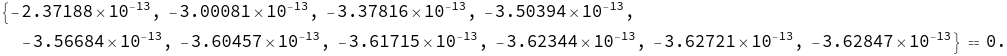

In [49]:
{x,y,w,z,v,a,b,c}={4.0002957022*^-06, 0.64999443632, 5.4215389827*^-16, 1.0100453005*^-12, 4.9483078049*^-13, 0.0012224017304, 0.0083619605438, 0.34041563773};

eeq1 = -k2 y y + (k1 - k9) y x - k11 w y + (k2 - k16 - k17) z y - k2 v y - k2 b y - 2 k2 c y - k1 z x + (k10 + k1) v x + k1 b x + 2 k1 c x + (k20 x + k25 v) / ntot == remain[[1]]
eq7
eq9
x + y + 2 w + z + 2 v + a + b + c

-20             -13             -13             -13             -13
{1.34245 10   , -1.78654 10   , -2.85847 10   , -3.21578 10   , -3.39444 10   , 
 
                -13             -13             -13             -13             -13
>    -3.50163 10   , -3.53736 10   , -3.55522 10   , -3.56594 10   , -3.56952 10   } == 
 
>   0.
False
False
1.
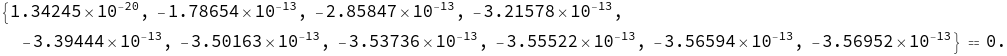

In [54]:
{x,y,w,z,v,a,b,c}={0.00001136340212655355, 0.6499886365921609, 0, 0, 0, 0.003613849178662948, 0.02445853608116408, 0.32192761474017295};

eeq1 = -k2 y y + (k1 - k9) y x - k11 w y + (k2 - k16 - k17) z y - k2 v y - k2 b y - 2 k2 c y - k1 z x + (k10 + k1) v x + k1 b x + 2 k1 c x + (k20 x + k25 v) / ntot == remain[[1]]
eq7
eq9
x + y + 2 w + z + 2 v + a + b + c

In [47]:
k1

-60
1.88692 10

In [64]:
kcutoff

-16            -13            -21            -13            -33
{10000., 7.24737 10   , 4.16988 10   , 1.56555 10   , 4.31417 10   , 1.36625 10   , 
 
             -12            -15            -9            -16        -10            -11
>   2.1858 10   , 3.53118 10   , 1.86054 10  , 2.45497 10   , 6.4 10   , 1.61589 10   , 
 
              -13           -15            -8            -9       -9            -10
>   2.05589 10   , 2.9262 10   , 1.04555 10  , 1.19473 10  , 7. 10  , 2.43151 10   , 
 
              -9       -8                                     -22                -57
>   1.20385 10  , 5. 10  , 0., 0., 0., 39.6864, 0., 1.16117 10   , 0., 8.44115 10   , 0.}